# Numproject 2

I have I have used cursor (Claude Haike2) to rewrite the dock strings and fix speelings and gramatical erros  

### TASK 1


### TASK 3

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from meshpy import triangle 


In [25]:
def make_simple_mesh(a0: float) -> tuple[np.array, np.array]:
    """
    a0: used
        create an numpy: np.array with possions in the xy plane
        give be a array with list 2d connections between the points in the xy plane

    """
    b0 = np.sqrt(3) * a0
    xy = np.array([[0, 0], [b0, 0], [b0 / 2, a0 / 2], [0, a0], [b0, a0]])

    edges = np.array([[0, 1], [0, 2], [0, 3], [1, 2], [1, 4], [2, 3], [2, 4], [3, 4]])

    return xy, edges

In [26]:
def plot_mesh(xy, edges):
    fig, ax = plt.subplots(1, 1)

    for edge in edges:
        ax.plot(xy[edge, 0], xy[edge, 1], "k")

    ax.scatter(xy[:, 0], xy[:, 1], s=20, color="red")
    ax.set_aspect("equal")

    plt.show()


### Task 2

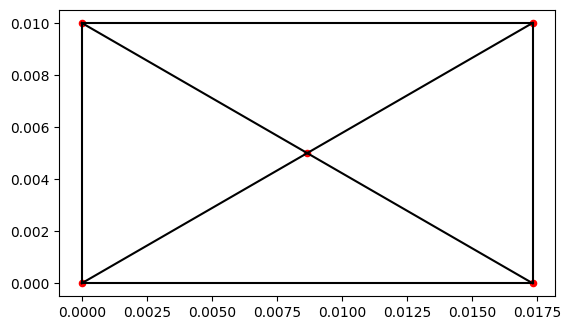

In [27]:
### TEST OF FUNCTIONS

a0 = 0.01
nodes, connections = make_simple_mesh(a0)
plot_mesh(nodes, connections)

In [28]:
### NEW FUNCTIONS

In [29]:
ell0__ = lambda nodes, connections:  np.linalg.norm(nodes[connections[:, 0]] - nodes[connections[:, 1]], axis=1)
ell0_ = ell0__(nodes, connections)


In [30]:
def spring_energy(xy: np.array, edges: np.array, k: float, ell0_: np.array) -> float:
    """
    Calculate the total elastic potential energy of the spring system.

    Parameters
    ----------
    xy : np.array
        Node positions, shape (n_nodes, 2).
    edges : np.array
        Edge connections, shape (n_edges, 2).
    k : float
        Spring constant.
    ell0_ : np.array
        Equilibrium lengths for each edge, shape (n_edges,).

    Returns
    -------
    float
        Total potential energy.
    """
    energy = 0.0
    for edge, ell0 in zip(edges, ell0_):
        i, j = edge
        rij = xy[j] - xy[i]
        ell = np.linalg.norm(rij)
        energy += 0.5 * k * (ell - ell0) ** 2
    return energy

In [31]:
def spring_forces(xy, edges, k, ell0_) -> np.array:
    """
    Calculate the net forces on each node due to the springs.

    Parameters
    ----------
    xy : np.array
        Node positions, shape (n_nodes, 2).
    edges : np.array
        Edge connections, shape (n_edges, 2).
    k : float
        Spring constant.
    ell0_ : np.array
        Equilibrium lengths for each edge, shape (n_edges,).

    Returns
    -------
    np.array
        Forces on each node, shape (n_nodes, 2).
    """
    N = xy.shape[0]
    forces = np.zeros_like(xy)
    for edge, ell0 in zip(edges, ell0_):
        i, j = edge
        rij = xy[j] - xy[i]
        ell = np.linalg.norm(rij)
        f_mag = k * (ell - ell0)
        f_vec = f_mag * (rij / ell)
        forces[i, :] += f_vec
        forces[j, :] -= f_vec
    return forces

### TASK 3 


The `spring_energy` function calculates the total potential energy stored in the spring system by summing the elastic energies for each spring, based on the current lengths and equilibrium lengths. The `spring_forces` function computes the net forces acting on each node due to the springs, which are derived from the negative gradient of the energy with respect to node positions. 

### New fucntions

In [32]:
ids_left = np.array([0, 3])
ids_right = np.array([1, 4])
ids_bottom = nodes[:,1] < 1e-12
ids_top = nodes[:,1] > 1e-12

nodes0 = nodes.copy()

### TASK 4

The energy minimum of a system corresponds to equilibrium, where the total potential energy is minimal.
In physics, for conservative forces (such as springs), this occurs at the point where the derivative of the energy with respect to the positions is zero.
This means that the net force on each particle is zero, since the force is given by the gradient of the energy.
Therefore, the sum of the forces on all particles is also zero, as the system is in equilibrium with no net motion.

### NEW FUNCTIONS

I removed the y-constraints on the left and right sides to allow contraction.
I also added a constraint that fixes the bottom nodes in the y-direction to prevent rigid body motion.
Apart from that, the setup is the same as given in the task; I only changed one constraint.
This change was made to remove a possible bug related to underfloating, and faster converging  (probably not strictly necessary, but it makes the setup safer).



In [33]:
def total_energy_jacobian(xy_flat, edges, k, K, ell0_, Lx_plate):
    """
    Calculate the Jacobian (gradient) of the total energy.

    Parameters
    ----------
    xy_flat : np.array
        Flattened node positions, shape (2*n_nodes,).
    edges : np.array
        Edge connections, shape (n_edges, 2).
    k : float
        Spring constant.
    K : float
        Constraint stiffness.
    ell0_ : np.array
        Equilibrium lengths, shape (n_edges,).
    Lx_plate : float
        Plate length in x-direction.

    Returns
    -------
    np.array
        Flattened gradient, shape (2*n_nodes,).
    """
    xy = xy_flat.reshape((-1, 2))
    grad = -spring_forces(xy, edges, k, ell0_)
    grad[ids_left, 0] += K * xy[ids_left, 0]
    grad[ids_right, 0] += K * (xy[ids_right, 0] - Lx_plate)
    # Remove the y-gradients on left and right sides
    # Add gradient for bottom y-constraint
    grad[ids_bottom, 1] += K * (xy[ids_bottom, 1] - nodes0[ids_bottom, 1])
    return grad.flatten()


In [34]:
def total_energy(xy_flat, edges, k, K, ell0_, Lx_plate, nodes0 = nodes0):
    """
    Calculate the total energy with additional constraints.

    Parameters
    ----------
    xy_flat : np.array
        Flattened node positions, shape (2*n_nodes,).
    edges : np.array
        Edge connections, shape (n_edges, 2).
    k : float
        Spring constant.
    K : float
        Constraint stiffness.
    ell0_ : np.array
        Equilibrium lengths, shape (n_edges,).
    Lx_plate : float
        Plate length in x-direction.

    Returns
    -------
    float
        Total energy.
    """
    xy = xy_flat.reshape((-1, 2))
    energy = spring_energy(xy, edges, k, ell0_)
    energy += 0.5 * K * ((xy[ids_left, 0]) ** 2).sum()
    energy += 0.5 * K * ((xy[ids_right, 0] - Lx_plate) ** 2).sum()
    energy += 0.5 * K * ((xy[ids_bottom, 1] - nodes0[ids_bottom, 1]) ** 2).sum()
    return energy


In [35]:
def total_energy_jacobian(xy_flat, edges, k, K, ell0_, Lx_plate):
    """
    Calculate the Jacobian (gradient) of the total energy.

    Parameters
    ----------
    xy_flat : np.array
        Flattened node positions, shape (2*n_nodes,).
    edges : np.array
        Edge connections, shape (n_edges, 2).
    k : float
        Spring constant.
    K : float
        Constraint stiffness.
    ell0_ : np.array
        Equilibrium lengths, shape (n_edges,).
    Lx_plate : float
        Plate length in x-direction.

    Returns
    -------
    np.array
        Flattened gradient, shape (2*n_nodes,).
    """
    xy = xy_flat.reshape((-1, 2))
    grad = -spring_forces(xy, edges, k, ell0_)
    grad[ids_left, 0] += K * xy[ids_left, 0]
    grad[ids_right, 0] += K * (xy[ids_right, 0] - Lx_plate)
    # Remove the y-gradients on left and right sides
    # Add gradient for bottom y-constraint
    grad[ids_bottom, 1] += K * (xy[ids_bottom, 1] - nodes0[ids_bottom, 1])
    return grad.flatten()

In [36]:
Lx0 = nodes[:, 0].max() - nodes[:, 0].min()
Ly0 = nodes[:, 1].max() - nodes[:, 1].min()


### TASK 5

x0: 0.017320508075688773, y0: 0.01


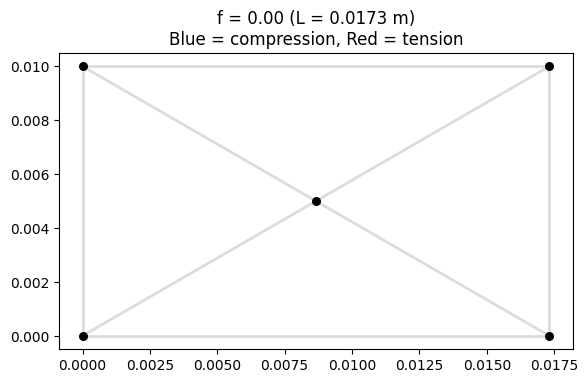

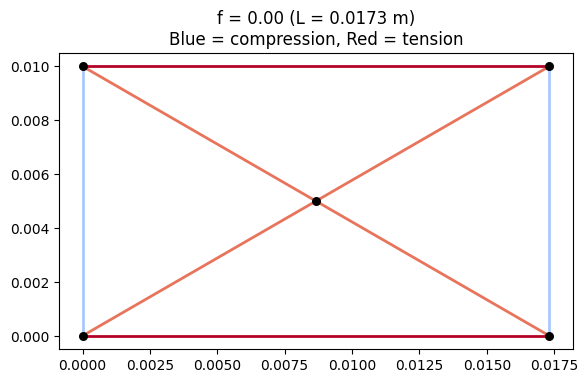

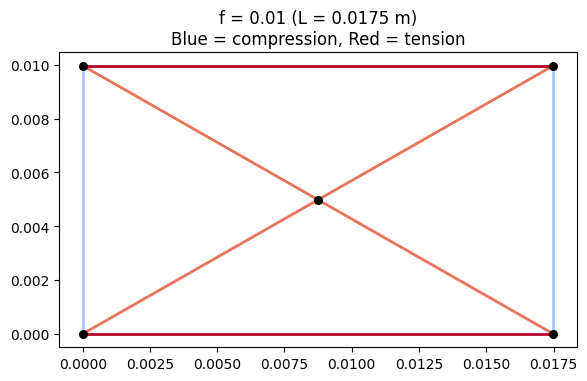

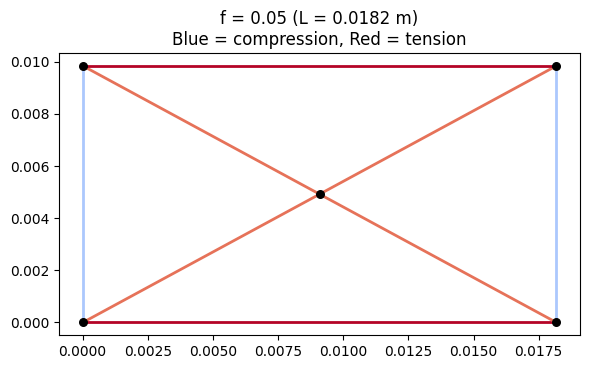

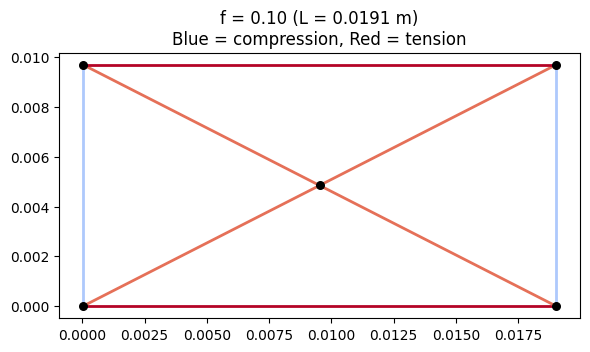

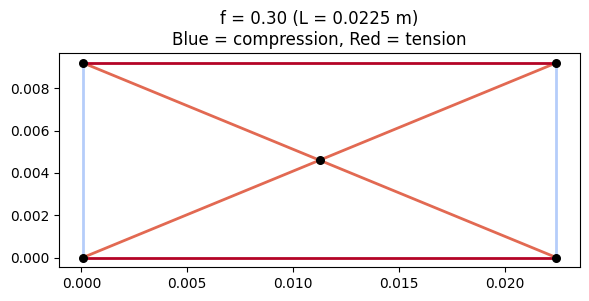

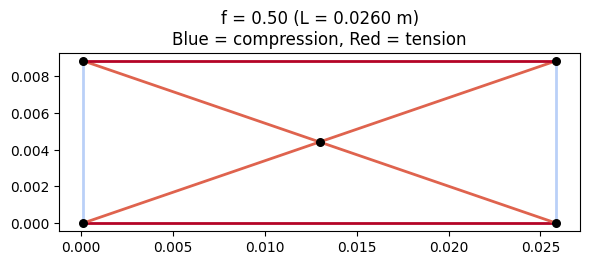

In [37]:
def plot_strain_distribution(stretch_factors = [0.0,0.0001,  0.01, 0.05, 0.1, 0.3, 0.5],
                            k=1e2,
                            K=1e4,
                            task6=False,
                            nodes0= nodes0,
                            connections = connections
                            ):
    """
    Plot the strain distribution in the mesh for various stretch factors.

    This function minimizes the total energy for each stretch factor to find the deformed node positions,
    calculates the strains for each edge, and visualizes the mesh with edges colored according to strain
    (blue for compression, red for tension).

    Parameters
    ----------
    stretch_factors : list of float, optional
        List of stretch factors to apply (default: [0.0, 0.01, 0.05, 0.1, 0.3, 0.5]).
    k : float, optional
        Spring constant (default: 1e5).
    K : float, optional
        Constraint stiffness (default: 1).
    task6 : bool, optional
        Placeholder for task 6 functionality (default: False).

    Returns
    -------
    None
        Displays plots for each stretch factor.
    """
    x0 = nodes[:, 0].max()
    y0 = nodes[:, 1].max()
    print(f"x0: {x0}, y0: {y0}")
    for f in stretch_factors:
        Lx_plate = Lx0 * (1 + f)

        xy_init = nodes0.copy()

        res = minimize(
            total_energy,
            xy_init.flatten(),
            args=(connections, k, K, ell0_, Lx_plate),
            method='Newton-CG',
            jac=total_energy_jacobian,
            tol=1e-12,
            options={'maxiter': 10000}
        )
        xy_def = res.x.reshape((-1, 2))
        if not task6:
            strains = []
            for edge, ell0 in zip(connections, ell0_):
                i, j = edge
                rij = xy_def[j] - xy_def[i]
                ell = np.linalg.norm(rij)
                strains.append((ell - ell0) / ell0)
            strains = np.array(strains)

            max_abs = max(np.abs(strains).max(), 1e-10)
            norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
            cmap = cm.coolwarm

            plt.figure(figsize=(6, 5))

            for e_idx, edge in enumerate(connections):
                color = cmap(norm(strains[e_idx]))
                plt.plot(xy_def[edge, 0], xy_def[edge, 1], color=color, linewidth=2)

            plt.scatter(xy_def[:, 0], xy_def[:, 1], s=30, color='black', zorder=5)
            plt.gca().set_aspect("equal")
            plt.title(f"f = {f:.2f} (L = {Lx0*(1+f):.4f} m)\nBlue = compression, Red = tension")

            # sm = cm.ScalarMappable(cmap=cmap, norm=norm)
            # sm.set_array([])
            # cbar = plt.colorbar(sm, fraction=0.046, pad=0.04)
            # cbar.set_label("Strain (ell-ell0)/ell0")

            plt.tight_layout()
            plt.show()
        if task6:
            new_max_x, new_max_y = xy_def[:, 0].max(), xy_def[:, 1].max()
            epsilon_x = (new_max_x - x0) / x0
            epsilon_y = (new_max_y - y0) / y0

            print(f" L : {Lx_plate:.4f} m")
            print(f"ratio change: {epsilon_y / epsilon_x:.4f}", end="\n\n")


plot_strain_distribution()

### TASK 6

In [38]:
plot_strain_distribution(task6=True)

x0: 0.017320508075688773, y0: 0.01
 L : 0.0173 m
ratio change: nan

 L : 0.0173 m
ratio change: -0.3289

 L : 0.0175 m
ratio change: -0.3268

 L : 0.0182 m
ratio change: -0.3183

 L : 0.0191 m
ratio change: -0.3079

 L : 0.0225 m
ratio change: -0.2695

 L : 0.0260 m
ratio change: -0.2373



/tmp/ipykernel_221026/948851284.py:85: RuntimeWarning: invalid value encountered in scalar divide
  print(f"ratio change: {epsilon_y / epsilon_x:.4f}", end="\n\n")


### TASK 7

In [39]:
# ...existing code...

def plot_strain_distribution(stretch_factors = [0.0,0.0001,  0.01, 0.05, 0.1, 0.3, 0.5],
                            k=1e2,
                            K=1e4,
                            task6=False,
                            nodes_r0= nodes0,
                            connections = connections
                            ):
    """
    Plot the strain distribution in the mesh for various stretch factors.

    This function minimizes the total energy for each stretch factor to find the deformed node positions,
    calculates the strains for each edge, and visualizes the mesh with edges colored according to strain
    (blue for compression, red for tension).

    Parameters
    ----------
    stretch_factors : list of float, optional
        List of stretch factors to apply (default: [0.0, 0.01, 0.05, 0.1, 0.3, 0.5]).
    k : float, optional
        Spring constant (default: 1e5).
    K : float, optional
        Constraint stiffness (default: 1).
    task6 : bool, optional
        Placeholder for task 6 functionality (default: False).

    Returns
    -------
    None
        Displays plots for each stretch factor.
    """
    # Compute mesh-specific parameters
    Lx0 = nodes_r0[:, 0].max() - nodes_r0[:, 0].min()
    x0 = nodes_r0[:, 0].max()
    y0 = nodes_r0[:, 1].max()
    
    # Compute boundary indices based on nodes0
    # global ids_left, ids_right, ids_bottom, nodes0_global
    # ids_left = np.where(np.abs(nodes0[:, 0] - nodes0[:, 0].min()) < 1e-12)[0]
    # ids_right = np.where(np.abs(nodes0[:, 0] - nodes0[:, 0].max()) < 1e-12)[0]
    # ids_bottom = np.where(np.abs(nodes0[:, 1] - nodes0[:, 1].min()) < 1e-12)[0]
    # nodes0_global = nodes0.copy()
    
    # Compute equilibrium lengths for the current mesh
    ell0_ = ell0__(nodes0, connections)
    
    print(f"x0: {x0}, y0: {y0}")
    for f in stretch_factors:
        Lx_plate = Lx0 * (1 + f)

        xy_init = nodes_r0.copy()

        res = minimize(
            total_energy,
            xy_init.flatten(),
            args=(connections, k, K, ell0_, Lx_plate),
            method='Newton-CG',
            jac=total_energy_jacobian,
            tol=1e-12,
            options={'maxiter': 10000}
        )
        xy_def = res.x.reshape((-1, 2))
        if not task6:
            strains = []
            for edge, ell0 in zip(connections, ell0_):
                i, j = edge
                rij = xy_def[j] - xy_def[i]
                ell = np.linalg.norm(rij)
                strains.append((ell - ell0) / ell0)
            strains = np.array(strains)

            max_abs = max(np.abs(strains).max(), 1e-10)
            norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
            cmap = cm.coolwarm

            plt.figure(figsize=(6, 5))

            for e_idx, edge in enumerate(connections):
                color = cmap(norm(strains[e_idx]))
                plt.plot(xy_def[edge, 0], xy_def[edge, 1], color=color, linewidth=2)

            plt.scatter(xy_def[:, 0], xy_def[:, 1], s=30, color='black', zorder=5)
            plt.gca().set_aspect("equal")
            plt.title(f"f = {f:.2f} (L = {Lx0*(1+f):.4f} m)\nBlue = compression, Red = tension")

            # sm = cm.ScalarMappable(cmap=cmap, norm=norm)
            # sm.set_array([])
            # cbar = plt.colorbar(sm, fraction=0.046, pad=0.04)
            # cbar.set_label("Strain (ell-ell0)/ell0")

            plt.tight_layout()
            plt.show()
        if task6:
            new_max_x, new_max_y = xy_def[:, 0].max(), xy_def[:, 1].max()
            epsilon_x = (new_max_x - x0) / x0
            epsilon_y = (new_max_y - y0) / y0

            print(f" L : {Lx_plate:.4f} m")
            print(f"ratio change: {epsilon_y / epsilon_x:.4f}", end="\n\n")


In [40]:
def task7():
    """
    Placeholder for task 7 functionality.
    """
    pass

In [41]:
def make_mesh(Lx, Ly, N):
    # Define the corners of the rectangle
    points = [(0, 0), (Lx, 0), (Lx, Ly), (0, Ly)]

    # Define the segments that connect the corners
    segments = [(0, 1), (1, 2), (2, 3), (3, 0)]

    # Create a mesh info object
    mesh_info = triangle.MeshInfo()
    mesh_info.set_points(points)
    mesh_info.set_facets(segments)

    # Build the mesh with a specified maximum area for each triangle
    max_area = (Lx * Ly) / N * np.sqrt(3) / 2
    mesh = triangle.build(mesh_info, max_volume=max_area)

    xy = np.array(mesh.points)

    # Extract unique edges from the mesh
    edges = []
    for tri in mesh.elements:
        tri = sorted(tri)  # Sort the indices to ensure uniqueness
        edges.append((tri[0], tri[1]))
        edges.append((tri[1], tri[2]))
        edges.append((tri[2], tri[0]))
    edges = np.array(list(set(edges)))  # Remove duplicates
    return xy, edges



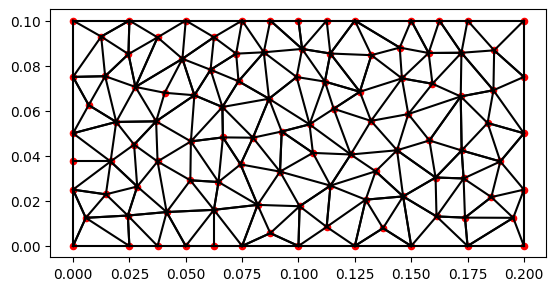

In [45]:
a0 = 0.01
nodes_r, connections_r = make_mesh(0.2,0.1,100)
plot_mesh(nodes_r, connections_r)
ell0_ = ell0__(nodes_r, connections)

In [48]:
global_connection = connections
# plot_strain_distribution(nodes_r0=nodes_r0, connections=connections_r, task6=True)

In [49]:
def plot_strain_distribution(
    stretch_factors = [0.0, 0.0001, 0.01, 0.05, 0.1, 0.3, 0.5],
    k=1e2,
    K=1e4,
    task6=False,
    nodes_r0=None,
    connections=None,
):
    """
    Plot the strain distribution in the mesh for various stretch factors.

    This function minimizes the total energy for each stretch factor to find the
    deformed node positions, calculates the strains for each edge, and visualizes
    the mesh with edges colored according to strain (blue = compression, red = tension).
    """
    # Fall back to global defaults if not given
    if nodes_r0 is None:
        nodes_r0 = nodes0
    if connections is None:
        connections = connections_global if "connections_global" in globals() else connections

    # Compute mesh-specific parameters from this mesh
    Lx0 = nodes_r0[:, 0].max() - nodes_r0[:, 0].min()
    x0  = nodes_r0[:, 0].max()
    y0  = nodes_r0[:, 1].max()

    # Equilibrium lengths MUST be computed on the same mesh that is being deformed
    ell0_ = ell0__(nodes_r0, connections)

    print(f"x0: {x0}, y0: {y0}")
    for f in stretch_factors:
        Lx_plate = Lx0 * (1 + f)

        # Initial guess: undeformed configuration of this mesh
        xy_init = nodes_r0.copy()

        res = minimize(
            total_energy,
            xy_init.flatten(),
            args=(connections, k, K, ell0_, Lx_plate),
            method="Newton-CG",
            jac=total_energy_jacobian,
            tol=1e-12,
            options={"maxiter": 10000},
        )
        xy_def = res.x.reshape((-1, 2))

        if not task6:
            # Compute strain in each edge: (ell - ell0)/ell0
            strains = []
            for edge, ell0 in zip(connections, ell0_):
                i, j = edge
                rij = xy_def[j] - xy_def[i]
                ell = np.linalg.norm(rij)
                strains.append((ell - ell0) / ell0)
            strains = np.array(strains)

            max_abs = max(np.abs(strains).max(), 1e-10)
            norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
            cmap = cm.coolwarm

            plt.figure(figsize=(6, 5))
            for e_idx, edge in enumerate(connections):
                color = cmap(norm(strains[e_idx]))
                plt.plot(xy_def[edge, 0], xy_def[edge, 1], color=color, linewidth=2)

            plt.scatter(xy_def[:, 0], xy_def[:, 1], s=30, color="black", zorder=5)
            plt.gca().set_aspect("equal")
            plt.title(
                f"f = {f:.2f} (L = {Lx0 * (1 + f):.4f} m)\n"
                "Blue = compression, Red = tension"
            )
            plt.tight_layout()
            plt.show()

        else:
            # Task 6: compute macroscopic strain ratio
            new_max_x, new_max_y = xy_def[:, 0].max(), xy_def[:, 1].max()
            epsilon_x = (new_max_x - x0) / x0
            epsilon_y = (new_max_y - y0) / y0

            print(f" L : {Lx_plate:.4f} m")
            if abs(epsilon_x) < 1e-14:
                print("ratio change: undefined (epsilon_x ≈ 0)\n")
            else:
                print(f"ratio change: {epsilon_y / epsilon_x:.4f}\n")
# Compute equilibrium lengths for the current mesh

x0: 0.017320508075688773, y0: 0.01


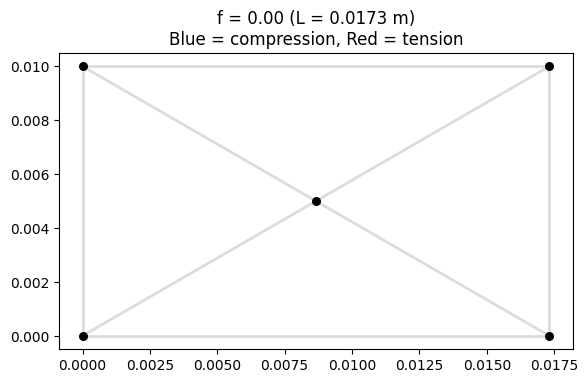

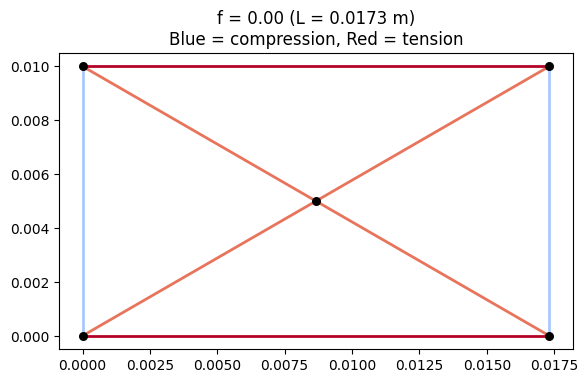

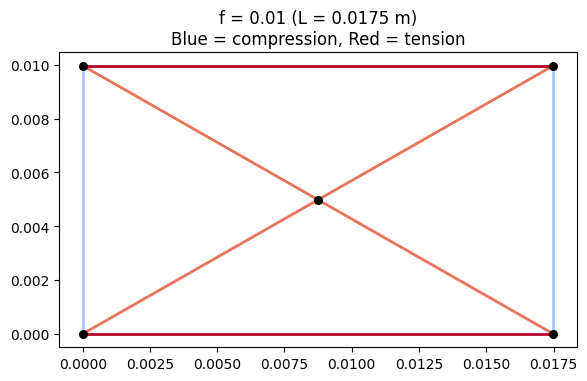

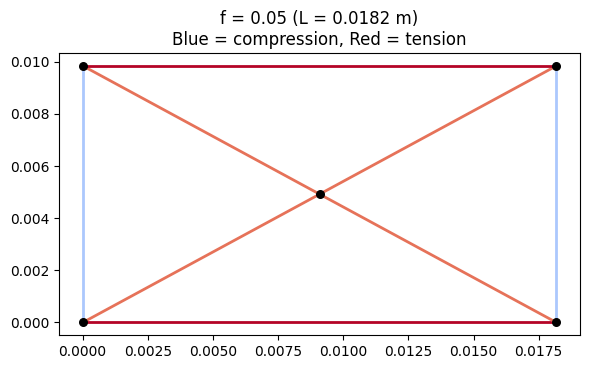

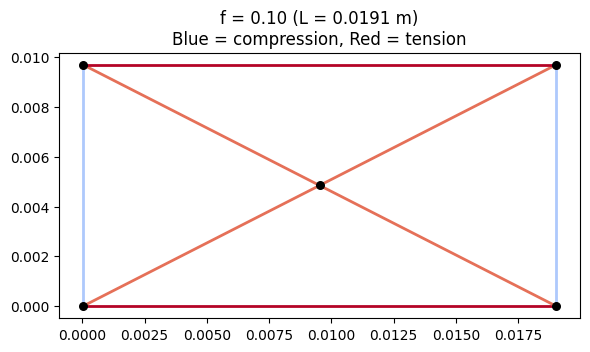

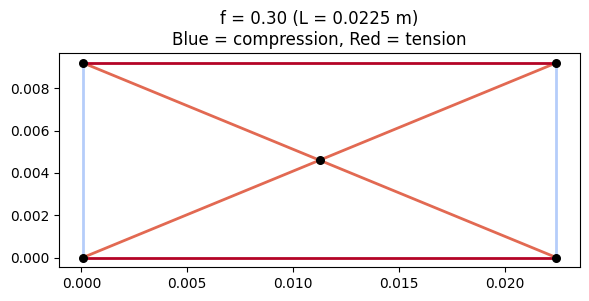

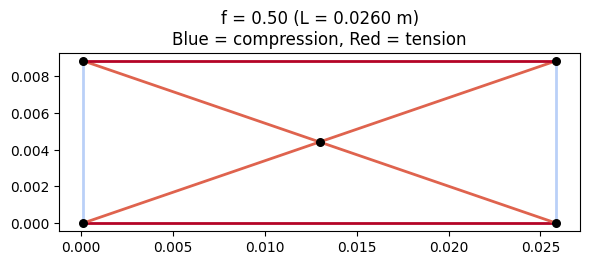

x0: 0.2, y0: 0.1


IndexError: boolean index did not match indexed array along axis 0; size of axis is 105 but size of corresponding boolean axis is 5

In [50]:
plot_strain_distribution(nodes_r0=nodes0, connections=connections)
plot_strain_distribution(nodes_r0=nodes_r, connections=connections_r)
plot_strain_distribution(nodes_r0=nodes_r, connections=connections_r, task6=True)